In [1]:
import warnings
warnings.filterwarnings("ignore")
import logging

import pandas as pd
import seaborn as sns
import numpy as np
import shap 
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




In [11]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../filter_top1.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"
sns.set_style("white")


In [3]:
models = pd.read_csv(SUMMARY_PATH)
history = pd.read_csv(HISTORY_PATH)
models

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,epochs,double_img,output_tab,backbone,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg
0,e108c95a38904af095098bbd5d999d4f,NaN,0.2,0.859873,0.791911,0.990991,0.847826,0.770701,0.708945,0.858108,0.559783,0.910150,0.875162,0.958525,0.796407,0.859418,0.799292,0.934631,0.663952,magneto,radam,0.0010,100.0,0.0,0.0,regnet16x,100.0,2022-11-20 16:46:38.043204,02:04:19.17,02:04:19.17,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Não,regnetx,regnety,503,486,79,79,286.75
1,344a717aeec64b46a3a5f7ac5a2fe59c,NaN,0.2,0.859873,0.828241,0.954955,0.913043,0.785096,0.720717,0.876216,0.565217,0.976705,0.967294,0.988479,0.946108,0.906040,0.875024,0.944839,0.805210,magneto,radam,0.0001,100.0,0.0,0.0,regnet16x,100.0,2022-11-20 18:51:39.825998,02:04:57.14,02:04:57.14,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Não,regnetx,regnety,251,393,4,22,167.50
2,1ff692349b5849acb0385390ad6fc09d,NaN,0.2,0.859873,0.811790,1.000000,0.804348,0.754076,0.665427,0.879550,0.451304,0.915141,0.874472,0.979263,0.796407,0.839917,0.759542,0.940461,0.578623,magneto,sgd,0.0100,100.0,0.0,0.0,inception,100.0,2022-11-25 13:42:10.070783,05:18:50.70,05:18:50.70,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Não,other,other,330,633,22,159,286.00
3,5caecd87eeba4102b08f51913795c325,NaN,0.2,0.866242,0.809929,1.000000,0.782609,0.787771,0.720317,0.883243,0.557391,0.943428,0.917313,0.988479,0.874251,0.893910,0.848961,0.950138,0.747784,magneto,ranger,0.0005,100.0,0.0,0.0,inception,100.0,2022-11-25 13:54:39.939485,05:20:55.56,05:20:55.56,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Não,other,other,345,397,26,23,197.75
4,8ca003378f704af1a4d892c639690663,NaN,0.2,0.859873,0.811790,1.000000,0.760870,0.784268,0.717394,0.878919,0.555870,0.916805,0.884372,0.983871,0.826347,0.871131,0.813923,0.942696,0.685150,magneto,ranger,0.0010,100.0,0.0,0.0,inception,100.0,2022-11-25 14:00:22.258456,05:23:01.43,05:23:01.43,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Não,other,other,331,420,23,35,202.25
5,11a6c666fb654482b8a3d2b2b7070a9d,NaN,0.2,0.885350,0.848903,0.990991,0.847826,0.789936,0.723695,0.883694,0.563696,0.925125,0.897272,0.983871,0.838323,0.884343,0.835301,0.945691,0.724910,magneto,radam,0.0010,100.0,0.0,0.0,regnet32x,100.0,2022-11-28 22:55:09.740563,14:03:27.73,14:03:27.73,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Não,Não,regnetx,regnety,231,372,1,14,154.50
6,3f932373851b4e5da34b440d9dcc89a0,NaN,0.2,0.955414,0.930278,1.000000,0.934783,0.867389,0.816278,0.939730,0.692826,0.981697,0.974434,1.000000,0.958084,0.929168,0.894759,0.972212,0.817305,magneto,adam,0.0005,100.0,0.0,5.0,regnet32y,100.0,2022-11-08 22:13:17.416383,04:13:22.53,04:13:22.53,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Sim,Não,regnety,regnety,29,122,22,73,61.50
7,9e209c2445544e3e864a2a21334806a8,NaN,0.2,0.949045,0.932139,1.000000,0.891304,0.873949,0.815444,0.956757,0.674130,0.993344,0.989866,1.000000,0.988024,0.939967,0.909548,0.978018,0.841078,magneto,ranger,0.0010,100.0,0.0,5.0,shuffle,100.0,2022-11-13 02:58:57.956263,04:10:35.47,04:10:35.47,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Sim,Não,other,other,20,125,15,75,58.75
8,3727dd4e99be4a829c8b4a2062da7cdb,NaN,0.2,0.949045,0.933999,1.000000,0.956522,0.889108,0.843732,0.953333,0.734130,0.981697,0.978117,1.000000,0.970060,0.941714,0.913115,0.977488,0.848743,magneto,radam,0.0010,100.0,0.0,5.0,shuffle,100.0,2022-11-13 02:59:02.886748,04:10:40.40,04:10:40.40,0.13.0+cu113,1.12.0+cu113,1.0,0,0,0,0,16,Sim,Não,other,other,15,48,10,38,27.75
9,c14f8aa402f646f784d13b0f691d898a,NaN,0.2,0.949045,0.938504,1.000000,0.934783,0.

In [4]:
history_filtered = history[history["model_id"].isin(models.model_id.values.tolist())]
history_filtered

,epochs,iter,train_acc_history,train_auc_history,train_loss_history,train_sensitivity_history,train_specificity_history,val_acc_history,val_auc_history,val_loss_history,val_sensitivity_history,val_specificity_history,backbone,Usando OCT,Dual Image,optim,lr,frac_val,k_fold,model_id,lr_history
270,1,1,0.685524,0.494916,654.655584,0.065868,0.923963,0.707006,0.500000,100.734395,0.000000,1.000000,resnet,Sim,Não,adam,0.01,0.2,NaN,c14f8aa402f646f784d13b0f691d898a,NaN
271,2,1,0.713810,0.497924,332.409479,0.011976,0.983871,0.808917,0.673913,243.743714,0.347826,1.000000,resnet,Sim,Não,adam,0.01,0.2,NaN,c14f8aa402f646f784d13b0f691d898a,NaN
272,3,1,0.851913,0.779581,231.249387,0.616766,0.942396,0.770701,0.608696,294.109058,0.217391,1.000000,resnet,Sim,Não,adam,0.01,0.2,NaN,c14f8aa402f646f784d13b0f691d898a,NaN
273,4,1,0.875208,0.814130,177.005912,0.676647,0.951613,0.904459,0.868782,43.981158,0.782609,0.954955,resnet,Sim,Não,adam,0.01,0.2,NaN,c14f8aa402f646f784d13b0f691d898a,NaN
274,5,1,0.906822,0.856281,156.200735,0.742515,0.970046,0.847134,0.739130,64.875953,0.478261,1.000000,resnet,Sim,Não,adam,0.01,0.2,NaN,c14f8aa402f646f784d13b0f691d898a,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48574,96,1,0.958403,0.938043,69.905865,0.892216,0.983871,0.923567,0.875930,38.140063,0.760870,0.990991,inception,NaN,NaN,ranger,0.01,0.2,NaN,0f96d68ebbfc40b695c7a4c44ad07982,NaN
48575,97,1,0.968386,0.956007,52.533333,0.928144,0.983871,0.942675,0.914904,27.520895,0.847826,0.981982,inception,NaN,NaN,ranger,0.01,0.2,NaN,0f96d68ebbfc40b695c7a4c44ad07982,NaN
48576,98,1,0.966722,0.956697,62.530955,0.934132,0.979263,0.949045,0.919409,29.933990,0.847826,0.990991,inception,NaN,NaN,ranger,0.01,0.2,NaN,0f96d68ebbfc40b695c7a4c44ad07982,NaN
48577,99,1,0.963394,0.948867,49.746936,0.916168,0.981567,0.936306,0.897669,33.520400,0.804348,0.990991,inception,NaN,NaN,ranger,0.01,0.2,NaN,0f96d68ebbfc40b695c7a4c44ad07982,NaN


In [5]:
history_filtered.columns

Index(['epochs', 'iter', 'train_acc_history', 'train_auc_history',
       'train_loss_history', 'train_sensitivity_history',
       'train_specificity_history', 'val_acc_history', 'val_auc_history',
       'val_loss_history', 'val_sensitivity_history',
       'val_specificity_history', 'backbone', 'Usando OCT', 'Dual Image',
       'optim', 'lr', 'frac_val', 'k_fold', 'model_id', 'lr_history'],
      dtype='object')

In [6]:
loss = history_filtered[history_filtered["val_loss_history"] < history_filtered["val_loss_history"].quantile(.99)]
loss["val_loss_history"] = loss["val_loss_history"] / 150
loss_melt= loss.melt('epochs', var_name='cols', value_name='vals')

In [8]:
loss_train_val = loss_melt[loss_melt.cols.isin(["val_loss_history","val_auc_history"])]

<AxesSubplot: xlabel='epochs', ylabel='vals'>

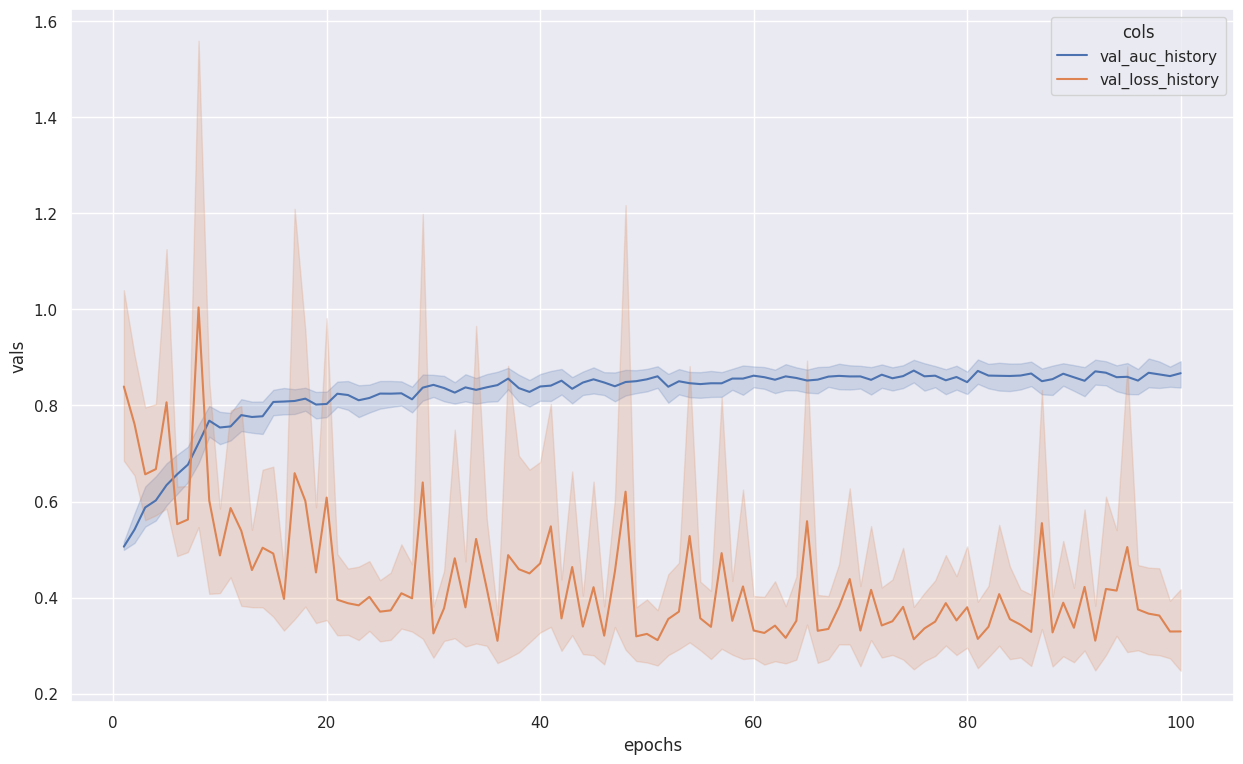

In [9]:
sns.set(rc={'figure.figsize':(15.0,9.0)})
fig, ax = pyplot.subplots(figsize=(15,9))

sns.lineplot(loss_train_val,x="epochs",y="vals",errorbar=("ci",95),hue="cols",ax=ax)

<AxesSubplot: xlabel='epochs', ylabel='val_auc_history'>

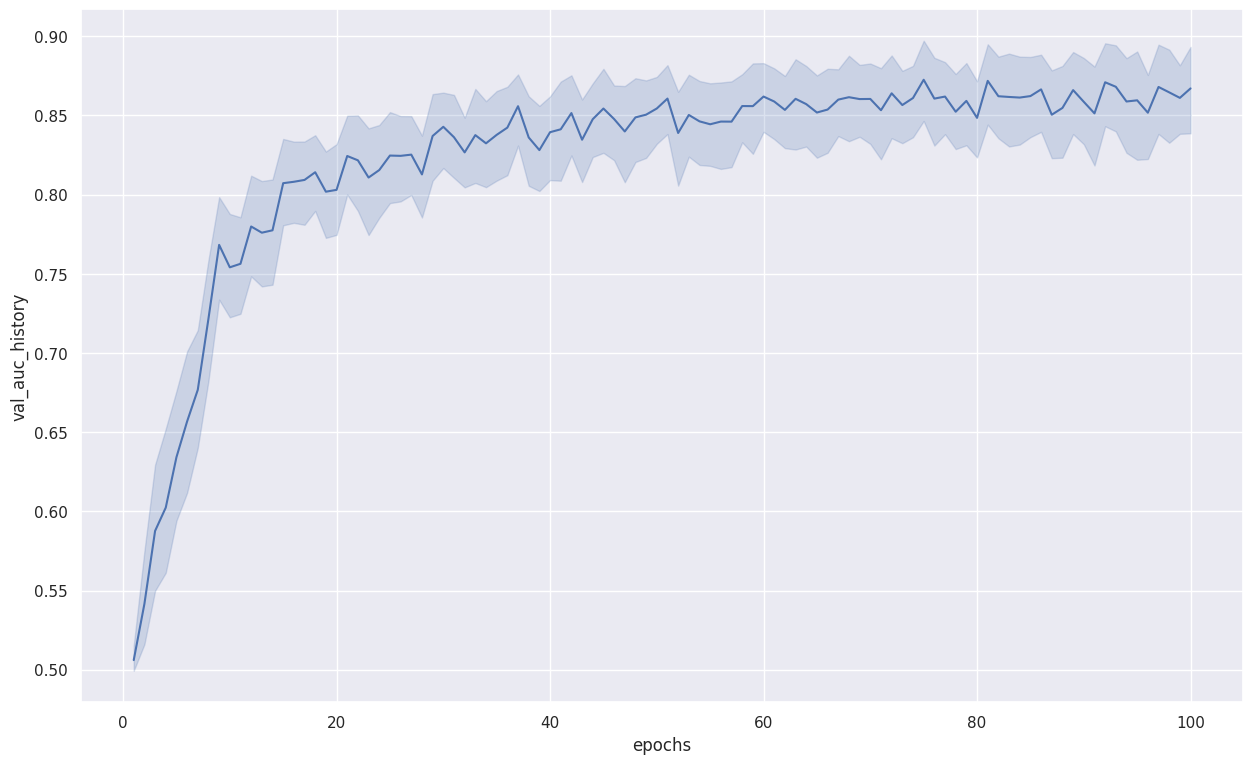

In [7]:
sns.set(rc={'figure.figsize':(15.0,9.0)})
fig, ax = pyplot.subplots(figsize=(15,9))

sns.lineplot(loss,x="epochs",y="val_auc_history",errorbar=("ci",95),ax=ax)

[Text(0, 0.5, 'Função de Custo'), Text(0.5, 0, 'Épocas')]

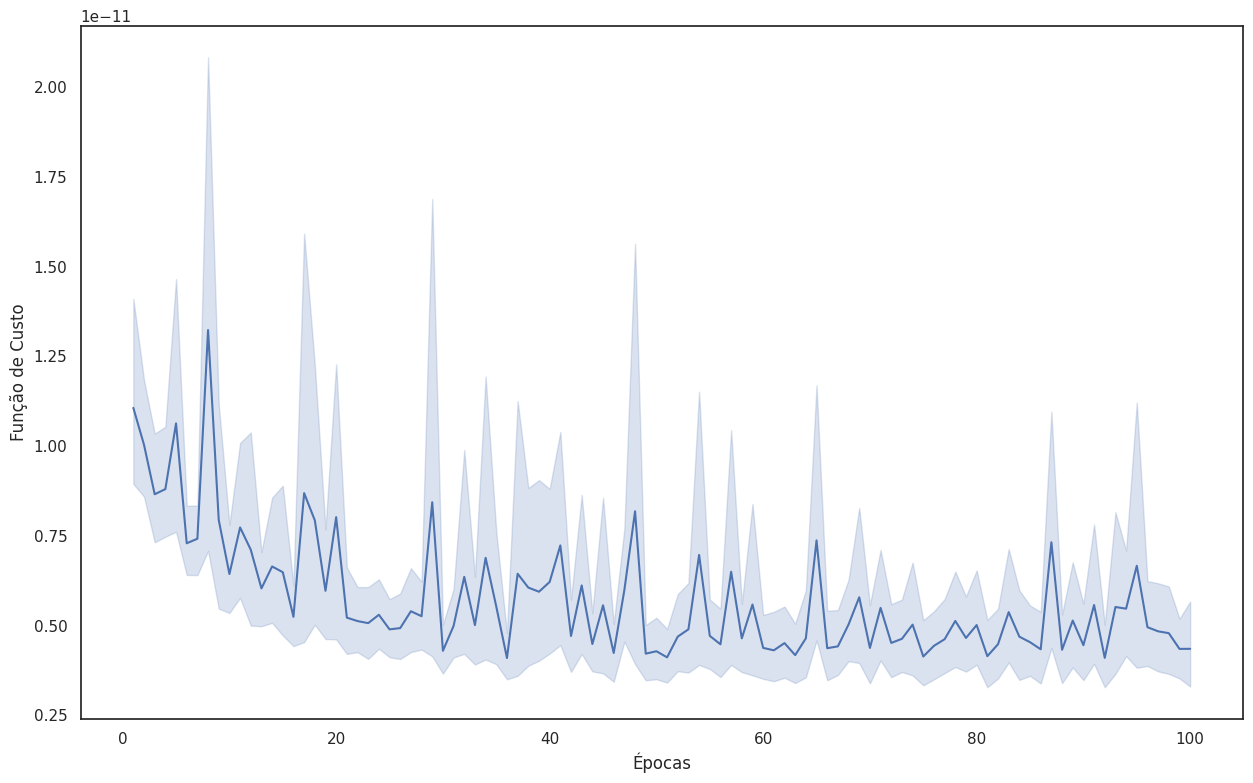

In [13]:
sns.set(rc={'figure.figsize':(15.0,9.0)},style="white")
fig, ax = pyplot.subplots(figsize=(15,9))
loss["val_loss_history"] = loss["val_loss_history"] / 150
ax = sns.lineplot(loss,x="epochs",y="val_loss_history",errorbar=("ci",95),ax=ax)
ax.set(ylabel='Função de Custo', xlabel='Épocas')